In [1]:
server = 'obi'
logBoth = True
output_type = 'phoneme'

if server == 'obi':
    dataDir = '/data/willett_data/competitionData/'
    if logBoth:
        dataSave = '/data3/willett_data/ptDecoder_ctc_both'
    else:
        dataSave = '/data3/willett_data/ptDecoder_ctc'
        
elif server == 'leia':
    dataDir = '/home3/skaasyap/willett/competitionData/'
    if logBoth:
        dataSave = '/data/willett_data/data_log_both'
    else:
        dataSave = '/data/willett_data/data'
        
        
if server == 'ec2':
    dataDir = '/data2/neural_data/competitiondata/'
    if logBoth:
        dataSave = '/data2/neural_data/ptDecoder_ctc_both'

if output_type == 'char':
    dataSave = f"{dataSave}_char"
    
if output_type == 'both':
    dataSave = f"{dataSave}_char_and_phoneme"



dataDir = "/home/uchiha/data/brain-to-text-25/card/t15_copyTask_neuralData/hdf5_data_final"
dataSave = "/home/uchiha/research/transformers_with_dietcorp/processed_data/card_data"


print(dataDir, dataSave)

/home/uchiha/data/brain-to-text-25/card/t15_copyTask_neuralData/hdf5_data_final /home/uchiha/research/transformers_with_dietcorp/processed_data/card_data


In [3]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/uchiha/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [4]:
import pickle

check_data = False

if check_data:

    if server == 'leia':
        
        with open('/home3/skaasyap/willett/data', 'rb') as f:
            data = pickle.load(f)
        #with open('/home3/skaasyap/willett/data_held_out_days', 'rb') as f:
        #    data_held_out = pickle.load(f)
        with open('/home3/skaasyap/willett/data_log_both', 'rb') as f:
            data_logged = pickle.load(f)
        with open('/home3/skaasyap/willett/data_log_both_held_out_days', 'rb') as f:
            data_logged_held_out = pickle.load(f)
            
        print(data['train'][0]['sentenceDat'][0].std(), data['train'][0]['sentenceDat'][0].mean())
        print(data_logged['train'][0]['sentenceDat'][0].std(), data_logged['train'][0]['sentenceDat'][0].mean())

    if server == 'obi':
        
        with open('/data/willett_data/ptDecoder_ctc', 'rb') as f:
            data = pickle.load(f)
        with open('/data/willett_data/ptDecoder_ctc_held_out_days', 'rb') as f:
            data_held_out = pickle.load(f)
        with open('/data/willett_data/ptDecoder_ctc_both', 'rb') as f:
            data_logged = pickle.load(f)
        with open('/data/willett_data/ptDecoder_ctc_both_held_out_days', 'rb') as f:
            data_logged_held_out = pickle.load(f)
        
#i = 10
#print(data['train'][i]['sentenceDat'][i].std(), data['train'][i]['sentenceDat'][i].mean())
#print(data_logged['train'][i]['sentenceDat'][i].std(), data_logged['train'][i]['sentenceDat'][i].mean())
#print(data_held_out['train'][i]['sentenceDat'][i].std(), data['train'][i]['sentenceDat'][i].mean())
#print(data_logged_held_out['train'][i]['sentenceDat'][i].std(), data_logged['train'][i]['sentenceDat'][i].mean())



In [5]:
sessionNames = [    "t15.2023.08.11", "t15.2023.08.18", "t15.2023.08.25", "t15.2023.09.01",
    "t15.2023.09.24", "t15.2023.10.01", "t15.2023.10.08", "t15.2023.10.15",
    "t15.2023.10.22", "t15.2023.11.04", "t15.2023.11.19", "t15.2023.12.03",
    "t15.2023.12.10", "t15.2023.12.29", "t15.2024.03.03", "t15.2024.03.15",
    "t15.2024.04.25", "t15.2024.05.10", "t15.2024.07.19", "t15.2024.07.28",
    "t15.2025.01.12", "t15.2025.03.16", "t15.2025.04.13",
    "t15.2023.08.13", "t15.2023.08.20", "t15.2023.08.27", "t15.2023.09.03",
    "t15.2023.09.29", "t15.2023.10.06", "t15.2023.10.13", "t15.2023.10.20",
    "t15.2023.11.03", "t15.2023.11.17", "t15.2023.11.26", "t15.2023.12.08",
    "t15.2023.12.17", "t15.2024.02.25", "t15.2024.03.08", "t15.2024.03.17",
    "t15.2024.04.28", "t15.2024.06.14", "t15.2024.07.21",
    "t15.2025.01.10", "t15.2025.03.14", "t15.2025.03.30",]
sessionNames.sort()

In [8]:
import re 
from g2p_en import G2p
import numpy as np

g2p = G2p()
PHONE_DEF = [
    'AA', 'AE', 'AH', 'AO', 'AW',
    'AY', 'B',  'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G',
    'HH', 'IH', 'IY', 'JH', 'K',
    'L', 'M', 'N', 'NG', 'OW',
    'OY', 'P', 'R', 'S', 'SH',
    'T', 'TH', 'UH', 'UW', 'V',
    'W', 'Y', 'Z', 'ZH'
]

PHONE_DEF_SIL = PHONE_DEF + ['SIL']

def phoneToId(p):
    return PHONE_DEF_SIL.index(p)
CHAR_VOCAB = [
    "<sp>",          # space token
    "!", ",", ".", "?", "'",   # punctuation (incl. apostrophe)
] + [chr(i) for i in range(ord('a'), ord('z') + 1)]  # 'a'..'z'

# Build mappings
_CHAR_TO_ID = {c: i for i, c in enumerate(CHAR_VOCAB)}
_ID_TO_CHAR = {i: c for c, i in _CHAR_TO_ID.items()}

# Convenience indices
SPACE_ID = _CHAR_TO_ID["<sp>"]

def charToId(c: str) -> int:
    """Map raw input char to ID, normalizing space and lowercase."""
    if c == " ":
        c = "<sp>"
    c = c.lower()
    return _CHAR_TO_ID[c]

def idToChar(i: int) -> str:
    return _ID_TO_CHAR[i]

In [9]:
import typing as tp
import h5py

def _load_h5py_file(file_path) -> tp.Iterable[tp.Dict[str, tp.Any]]:
    # Open the hdf5 file for that day
    with h5py.File(file_path, "r") as f:

        keys = list(f.keys())

        # For each trial in the selected trials in that day
        for key in keys:
            g = f[key]

            data = {}

            neural_features = g["input_features"][:]
            n_time_steps = g.attrs["n_time_steps"]
            seq_class_ids = g["seq_class_ids"][:] if "seq_class_ids" in g else None
            seq_len = g.attrs["seq_len"] if "seq_len" in g.attrs else None
            transcription = g["transcription"][:] if "transcription" in g else None
            sentence_label = (
                g.attrs["sentence_label"][:] if "sentence_label" in g.attrs else None
            )
            session = g.attrs["session"]
            block_num = g.attrs["block_num"]
            trial_num = g.attrs["trial_num"]

            data["neural_features"] = neural_features
            data["n_time_steps"] = n_time_steps
            data["seq_class_ids"] = seq_class_ids
            data["seq_len"] = seq_len
            data["transcriptions"] = transcription
            data["sentence_label"] = sentence_label
            data["session"] = session
            data["block_num"] = block_num
            data["trial_num"] = trial_num

            yield data



In [11]:
import scipy

def loadFeaturesAndNormalize(hdf5Path, logBoth):
    
    all_data = list(_load_h5py_file(hdf5Path))
    merged = {key: [np.atleast_1d(data[key]) for data in all_data] for key in all_data[0].keys()}
    
    # keep only selected channels
    input_features = merged.pop("neural_features")

    # change key names 
    frame_lens = merged.pop("n_time_steps")
    transcriptions = merged.pop("sentence_label")
    
    # remove unused keys
    merged.pop("transcriptions", None)
    merged.pop("session", None)
    
    # block-wise neural normalization
    block_ids = np.squeeze(merged['block_num'])
    blockList = np.unique(block_ids)
    blocks = []
    for b in range(len(blockList)):
        sentIdx = np.argwhere(block_ids==blockList[b])
        sentIdx = sentIdx[:,0].astype(np.int32)
        blocks.append(sentIdx)


    for b in range(len(blocks)):
        feats = np.concatenate(input_features[blocks[b][0]:(blocks[b][-1]+1)], axis=0)
        # feats = np.concatenate(input_features[blocks[b][0]:(blocks[b][-1]+1)], axis=0)

        feats_mean = np.mean(feats, axis=0, keepdims=True)
        feats_std = np.std(feats, axis=0, keepdims=True)
        for i in blocks[b]:
            # input_features[i] = reorder_electrode_idxs(input_features[i])
            input_features[i] = (input_features[i] - feats_mean) / (feats_std + 1e-8)
            print(f"Normalized block {b}, trial {i}, mean {np.mean(input_features[i])}, std {np.std(input_features[i])}")

    #convert to tfRecord file
    session_data = {
        'inputFeatures': input_features,
        'transcriptions': transcriptions,
        'frameLens': frame_lens, 
        'blockNums': block_ids,
    }

    return session_data


In [12]:
import os
import re
import numpy as np

def getDataset(fileName, logBoth, output_type):
    print(f"Processing file: {fileName}")
    session_data = loadFeaturesAndNormalize(fileName, logBoth)

    allDat = []
    trueSentences = []
    seq_char = []     # for characters (primary text)
    seq_phone = []    # for phonemes  (secondary text2, only when output_type == 'both')

    for x in range(len(session_data['inputFeatures'])):
        allDat.append(session_data['inputFeatures'][x])
        trueSentences.append(session_data['transcriptions'][x])

        # clean sentence
        thisTranscription = str(session_data['transcriptions'][x]).strip()
        thisTranscription = re.sub(r'[^a-zA-Z\- \']', '', thisTranscription)
        thisTranscription = thisTranscription.replace('--', '').lower()
        addInterWordSymbol = True
        maxSeqLen = 500

        # ----- build phoneme ids (used for 'phoneme' or 'both') -----
        if output_type in ('phoneme', 'both'):
            phonemes = []
            for p in g2p(thisTranscription):
                if addInterWordSymbol and p == ' ':
                    phonemes.append('SIL')
                p = re.sub(r'[0-9]', '', p)           # remove stress
                if re.match(r'[A-Z]+', p):            # keep only phoneme labels
                    phonemes.append(p)
            if addInterWordSymbol:
                phonemes.append('SIL')

            seqLenP = len(phonemes)
            seqIDsP = np.zeros([maxSeqLen], dtype=np.int32)
            seqIDsP[:seqLenP] = [phoneToId(p) + 1 for p in phonemes]

        # ----- build char ids (used for 'char' or 'both') -----
        if output_type in ('char', 'both'):
            txt = thisTranscription.replace('-', ' ')
            characters = []
            for c in txt:
                if addInterWordSymbol and c == ' ':
                    characters.append('<sp>')
                else:
                    characters.append(c)
            if addInterWordSymbol:
                characters.append('<sp>')

            seqLenC = len(characters)
            seqIDsC = np.zeros([maxSeqLen], dtype=np.int32)
            try:
                seqIDsC[:seqLenC] = [charToId(c) + 1 for c in characters]
            except Exception:
                print(txt)

        # ----- save according to output_type -----
        if output_type == 'phoneme':
            seq_char.append(seqIDsP)          # keep same key names as original ('text' holds the chosen output)
        elif output_type == 'char':
            seq_char.append(seqIDsC)
        elif output_type == 'both':
            seq_char.append(seqIDsC)          # 'text'  -> characters
            seq_phone.append(seqIDsP)         # 'text2' -> phonemes
        else:
            print("invalid output type, must be 'phoneme', 'char', or 'both'")
            return 0

    # ----- package dataset -----
    newDataset = {
        'sentenceDat': allDat,
        'transcriptions': trueSentences,
        'text': seq_char,                     # primary (chars for 'both')
        'blockNums': session_data['blockNums']
    }

    # lengths for primary text
    timeSeriesLens = [arr.shape[0] for arr in newDataset['sentenceDat']]
    textLens = []
    for arr in newDataset['text']:
        zeroIdx = np.argwhere(arr == 0)
        textLens.append(zeroIdx[0, 0] if zeroIdx.size else arr.shape[0])

    newDataset['timeSeriesLens'] = np.array(timeSeriesLens)
    newDataset['textLens'] = np.array(textLens)
    newDataset['textPerTime'] = newDataset['textLens'].astype(np.float32) / newDataset['timeSeriesLens'].astype(np.float32)

    # add phoneme versions when requested
    if output_type == 'both':
        newDataset['text2'] = seq_phone
        textLens2 = []
        for arr in newDataset['text2']:
            zeroIdx = np.argwhere(arr == 0)
            textLens2.append(zeroIdx[0, 0] if zeroIdx.size else arr.shape[0])
        newDataset['textLens2'] = np.array(textLens2)
        newDataset['textPerTime2'] = newDataset['textLens2'].astype(np.float32) / newDataset['timeSeriesLens'].astype(np.float32)

    return newDataset


In [13]:
# test contains the last block of each day

In [14]:
trainDatasets = []
testDatasets = []
competitionDatasets = []
splits = ['train', 'val', 'test']

for dayIdx in range(len(sessionNames)):
    
    for split in splits:
        data_path = os.path.join(dataDir, sessionNames[dayIdx], f"data_{split}.hdf5")
        if os.path.exists(data_path):
            dataset = getDataset(data_path, logBoth, output_type=output_type)
            if split == 'train':
                trainDatasets.append(dataset)
            elif split == 'val':
                testDatasets.append(dataset)
            elif split == 'test':
                competitionDatasets.append(dataset)
    
       
        
            

Processing file: /home/uchiha/data/brain-to-text-25/card/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.11/data_train.hdf5
Normalized block 0, trial 0, mean 0.017654864117503166, std 1.0093213319778442
Normalized block 0, trial 1, mean -0.013106772676110268, std 0.9974881410598755
Normalized block 0, trial 2, mean -0.027473799884319305, std 0.9811017513275146
Normalized block 0, trial 3, mean -0.018657147884368896, std 0.9919215440750122
Normalized block 0, trial 4, mean -0.04549815133213997, std 0.97540283203125
Normalized block 0, trial 5, mean -0.00888905394822359, std 0.9806039333343506
Normalized block 0, trial 6, mean 0.002173424232751131, std 1.0008825063705444
Normalized block 0, trial 7, mean 0.005581732839345932, std 1.0057849884033203
Normalized block 0, trial 8, mean -0.022889619693160057, std 0.9919020533561707
Normalized block 0, trial 9, mean -0.0007038554176688194, std 1.0027819871902466
Normalized block 0, trial 10, mean 0.014811350032687187, std 1.005589127540588

In [16]:
allDatasets = {}
allDatasets['train'] = trainDatasets
allDatasets['test'] = testDatasets
allDatasets['competition'] = competitionDatasets


with open(dataSave, 'wb') as handle:
    pickle.dump(allDatasets, handle)

In [17]:
def return_train_validation_blocks(unique_blocks, K, fold_number):
    
    """
    list unique_blocks: unique blocks in that day
    int K: the number of folds
    fold_number: current fold
    
    Returns the blocks that should be used for training and validation. 
    
    * This function assumes the last block was already used for validation, since this was the default competition settings.
    """
    
    n_blocks_for_val = len(unique_blocks) - 1
    n_blocks_per_fold = np.ceil(n_blocks_for_val / K)
    
    start_idx = int(fold_number*n_blocks_per_fold)
    end_idx = int(min(n_blocks_for_val, (fold_number+1)*n_blocks_per_fold))
        
    blocks_for_val = unique_blocks[start_idx:end_idx]
    
    return np.setdiff1d(unique_blocks, blocks_for_val), blocks_for_val

def partition_by_blocks(dataset, train_blocks, test_blocks):
    
    """Split dataset into train and test portions using blockNums."""
    train_set, test_set = {}, {}
    
    for key, values in dataset.items():
        # blockNums is special: we need it to decide the split
        if key == "blockNums":
            continue

        # Assume dataset["blockNums"] is aligned with all other keys
        train_set[key] = [v for v, b in zip(values, dataset["blockNums"]) if b in train_blocks]
        test_set[key]  = [v for v, b in zip(values, dataset["blockNums"]) if b in test_blocks]

    # Also save the blockNums
    train_set["blockNums"] = [b for b in dataset["blockNums"] if b in train_blocks]
    test_set["blockNums"]  = [b for b in dataset["blockNums"] if b in test_blocks]

    return train_set, test_set

In [18]:
import pickle
trainSentences_arr = []

for fold_number in [0,1,2,3,4]:
    
    trainSentences = 0
    trainDatasets = []
    testDatasets = []
    competitionDatasets = []
        
    for dayIdx in range(len(sessionNames)):
        
        trainDataset = getDataset(dataDir + '/train/' + sessionNames[dayIdx] + '.mat', logBoth, output_type=output_type)
        testDataset = getDataset(dataDir + '/test/' + sessionNames[dayIdx] + '.mat', logBoth, output_type=output_type)
        
        combined = {}
        
        # combine train and validation data. 
        for key in trainDataset.keys():
            if type(trainDataset[key]) == np.ndarray:
                combined[key] = np.concatenate((trainDataset[key], testDataset[key]))
            else:
                combined[key] = trainDataset[key] + testDataset[key]
                
        block_numbers = np.unique(combined['blockNums'])
                
        train_blocks, validation_blocks = return_train_validation_blocks(block_numbers, K=5, fold_number=fold_number)
        
        trainDataset, testDataset = partition_by_blocks(combined, train_blocks, validation_blocks)
        
        trainSentences += len(trainDataset['sentenceDat'])

        trainDatasets.append(trainDataset)
        testDatasets.append(testDataset)

        if os.path.exists(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat'):
            dataset = getDataset(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat', logBoth, output_type=output_type)
            competitionDatasets.append(dataset)
            
    trainSentences_arr.append(trainSentences)
    
    print(f"Fold number {trainSentences}")
    
    allDatasets = {}
    allDatasets['train'] = trainDatasets
    allDatasets['test'] = testDatasets
    allDatasets['competition'] = competitionDatasets
    
    dataSave_fold = f"{dataSave}_fold_number_{fold_number}"

    with open(dataSave_fold, 'wb') as handle:
        pickle.dump(allDatasets, handle)
        
    print("Saved data")

Processing file: /home/uchiha/data/brain-to-text-25/card/t15_copyTask_neuralData/hdf5_data_final/train/t15.2023.08.11.mat


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/uchiha/data/brain-to-text-25/card/t15_copyTask_neuralData/hdf5_data_final/train/t15.2023.08.11.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
dataSave

'/home/behemoth/research/transformers_with_dietcorp/processed_data/data'

In [ ]:
import pickle


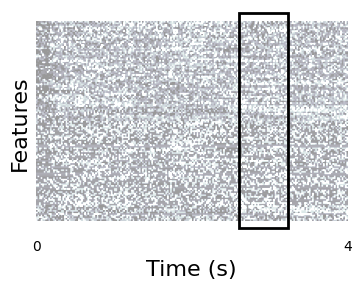

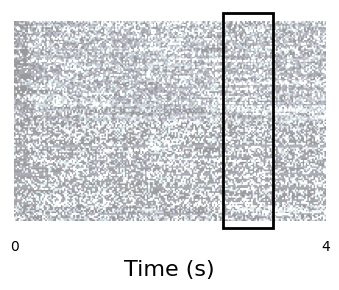

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

data = trainDatasets[0]['sentenceDat'][10].T
np.save('figure1_neural_data', data)

plt.figure(figsize=(5, 3))
plt.imshow(trainDatasets[0]['sentenceDat'][10].T[:128, 0:200], clim=[-1, 1], alpha=0.4, cmap='bone')
plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("Features", fontsize=16)
plt.tick_params(axis='x', length=0)
plt.xticks([0, 200], [0, 4])
plt.yticks([])


# Transparent rectangle
rect = patches.Rectangle((130, -5), 32, 138,
                         facecolor='none', edgecolor='black', linewidth=2, clip_on=False)
plt.gca().add_patch(rect)


# Adjust y-limits to show full rectangle
plt.ylim(-10, 135)

# Despine all axes
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.figure(figsize=(5, 3))
plt.imshow(trainDatasets[0]['sentenceDat'][10].T[:128, 0:200], clim=[-1, 1], alpha=0.4, cmap='bone')
plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("")
plt.tick_params(axis='x', length=0)
plt.xticks([0, 200], [0, 4])
plt.yticks([])


# Transparent rectangle
rect = patches.Rectangle((134, -5), 32, 138,
                         facecolor='none', edgecolor='black', linewidth=2, clip_on=False)
plt.gca().add_patch(rect)


# Adjust y-limits to show full rectangle
plt.ylim(-10, 135)

# Despine all axes
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()



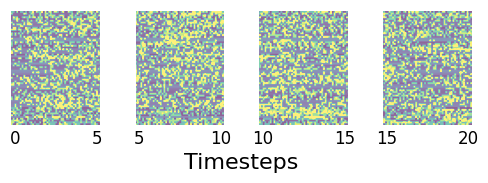

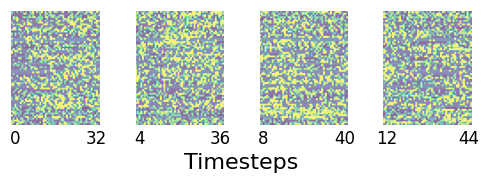

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

data = trainDatasets[0]['sentenceDat'][10].T[:64, :260]


fig, ax = plt.subplots(figsize=(5,4))
ax.imshow(data, vmin=-1, vmax=1, origin='lower', alpha=0.6)
ax.set_yticks([])
centers = [60, 130, 200]
rect_width = 20
rect_height = data.shape[0]  # full height of the electrode axis

# Add rectangles
y_start = -0.5  # start slightly below the image
rect_height = data.shape[0] + 1  # extend slightly beyond top

for x_center in centers:
    rect = patches.Rectangle((x_center - rect_width / 2, y_start), rect_width, rect_height,
                             linewidth=0, facecolor='white', alpha=1.0)
    ax.add_patch(rect)
sns.despine(trim=True, top=True, right=True, left=True, bottom=True)

# Set x-ticks at the edges of each patch
ax.set_xticks([])
tick_positions = [0, 50, 70, 120, 140, 190, 210, 260]
tick_positions = [2, 48, 72, 118, 142, 188, 212, 258]
ax.set_xticks(tick_positions)
tick_labels = np.array([0, 50, 50, 100, 100, 150, 150, 200])/10 # 4 labels for the 4 patches
ax.set_xticklabels([str(int(lbl)) for lbl in tick_labels])
ax.tick_params(axis='x', length=0)  # Set tick mark length to 0 on x-axis
ax.tick_params(axis='x', labelsize=12)  

ax.set_xlabel("Timesteps", fontsize=16)

plt.ylim(-0.5, data.shape[0] + 0.5)
plt.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(5,4))
ax.imshow(data, vmin=-1, vmax=1, origin='lower', alpha=0.6)
ax.set_yticks([])
centers = [60, 130, 200]
rect_width = 20
rect_height = data.shape[0]  # full height of the electrode axis

# Add rectangles
y_start = -0.5  # start slightly below the image
rect_height = data.shape[0] + 1  # extend slightly beyond top

for x_center in centers:
    rect = patches.Rectangle((x_center - rect_width / 2, y_start), rect_width, rect_height,
                             linewidth=0, facecolor='white', alpha=1.0)
    ax.add_patch(rect)
sns.despine(trim=True, top=True, right=True, left=True, bottom=True)

# Set x-ticks at the edges of each patch
ax.set_xticks([])
tick_positions = [0, 50, 70, 120, 140, 190, 210, 260]
tick_positions = [2, 48, 72, 118, 142, 188, 212, 258]
ax.set_xticks(tick_positions)
tick_labels = [0, 32, 4, 36, 8, 40, 12, 44] # 4 labels for the 4 patches
ax.set_xticklabels([str(int(lbl)) for lbl in tick_labels])
ax.tick_params(axis='x', length=0)  # Set tick mark length to 0 on x-axis
ax.tick_params(axis='x', labelsize=12)  

ax.set_xlabel("Timesteps", fontsize=16)

plt.ylim(-0.5, data.shape[0] + 0.5)
plt.tight_layout()
plt.show()

In [ ]:
def combine_dicts(dict1, dict2):
    
    combined_dict = {}
    for key in dict1.keys():
        if key in ['sentenceDat', 'transcriptions', 'phonemes']: 
            combined_dict[key] = dict1[key] + dict2[key]
        else:
            combined_dict[key] = np.concatenate([dict1[key], dict2[key]])
        
    return combined_dict

In [ ]:
sessionNames

['t12.2022.04.28',
 't12.2022.05.05',
 't12.2022.05.17',
 't12.2022.05.19',
 't12.2022.05.24',
 't12.2022.05.26',
 't12.2022.06.02',
 't12.2022.06.07',
 't12.2022.06.14',
 't12.2022.06.16',
 't12.2022.06.21',
 't12.2022.06.23',
 't12.2022.06.28',
 't12.2022.07.05',
 't12.2022.07.14',
 't12.2022.07.21',
 't12.2022.07.27',
 't12.2022.07.29',
 't12.2022.08.02',
 't12.2022.08.11',
 't12.2022.08.13',
 't12.2022.08.18',
 't12.2022.08.23',
 't12.2022.08.25']

# Held out days testing

In [ ]:
competitionDays = []
for dayIdx in range(len(sessionNames)):
    if os.path.exists(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat'):
        competitionDays.append(dayIdx)
print(competitionDays)

for cd in competitionDays:
    print(sessionNames[cd])

[4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 18, 19, 20]
t12.2022.05.24
t12.2022.05.26
t12.2022.06.02
t12.2022.06.07
t12.2022.06.14
t12.2022.06.16
t12.2022.06.21
t12.2022.06.28
t12.2022.07.05
t12.2022.07.14
t12.2022.07.21
t12.2022.07.27
t12.2022.08.02
t12.2022.08.11
t12.2022.08.13


In [ ]:
trainDatasets = []
testDatasets = []
competitionDatasets = []

condition = 1

if condition == 0:
    evaluation_days = ['07.21', '07.27', '08.02', '08.11', '08.13'] 
if condition == 1:
    evaluation_days = ['06.28', '07.05', '07.14', '07.21', '07.27', '08.02', '08.11', '08.13'] 
    
skip_days = ['07.29']

trainCount = 0
evalCount = 0
print(logBoth)
for dayIdx in range(len(sessionNames[:-3])):
    
    if sessionNames[dayIdx][-5:] in skip_days:
        print("Skipping day: ", sessionNames[dayIdx][-5:])
        continue
        
    if sessionNames[dayIdx][-5:] in evaluation_days:
        
        evalCount += 1
        
        print(f"Placing {sessionNames[dayIdx]} in test/comp")
        
        # put both train and test data for held-out days into "test (really val)".
        testDataset1 = getDataset(dataDir + '/train/' + sessionNames[dayIdx] + '.mat', logBoth)
        testDataset2 = getDataset(dataDir + '/test/' + sessionNames[dayIdx] + '.mat', logBoth)
        testDataset = combine_dicts(testDataset1, testDataset2)
        testDatasets.append(testDataset)
        
        # only testing on these held-out days now. 
        trainDataset, testDataset = partition_by_blocks(combined, train_blocks, validation_blocks)
        if os.path.exists(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat'):
            dataset = getDataset(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat', logBoth)
            competitionDatasets.append(dataset)
            
    else:
        
        trainCount += 1
        
        print(f"Train {sessionNames[dayIdx]} in train")
        
        # put both train and test data for non held-out days into train
        trainDataset1 = getDataset(dataDir + '/train/' + sessionNames[dayIdx] + '.mat', logBoth)
        trainDataset2 = getDataset(dataDir + '/test/' + sessionNames[dayIdx] + '.mat', logBoth)
        trainDataset = combine_dicts(trainDataset1, trainDataset2)
        trainDatasets.append(trainDataset)
        
        
print("Training days: ", trainCount)
print("Eval days: ", evalCount)

True
Train t12.2022.04.28 in train


TypeError: getDataset() missing 1 required positional argument: 'output_type'

In [ ]:
print(dataSave)

/home/behemoth/research/transformers_with_dietcorp/processed_data/data


In [ ]:
import pickle
allDatasets = {}
allDatasets['train'] = trainDatasets
allDatasets['test'] = testDatasets
allDatasets['competition'] = competitionDatasets

if condition == 0: 
    dataSave_held_out_days = f"{dataSave}_held_out_days"
if condition == 1:
    dataSave_held_out_days = f"{dataSave}_held_out_days_big_0"
    
print(dataSave_held_out_days)
with open(dataSave_held_out_days, 'wb') as handle:
    pickle.dump(allDatasets, handle)

/home/behemoth/research/transformers_with_dietcorp/processed_data/data_held_out_days_big_0


In [ ]:
print("max day held out 0 ", 24 - 3 - 6 - 1)
print("max day held out 1 ", 24 -9 - 5 - 1)
print("max day held out 2 ", 24 - 15 - 5 - 1)

max day held out 0  14
max day held out 1  9
max day held out 2  3


In [ ]:
import numpy as np
evaluation_days = ['07.21', '07.27', '08.02', 
                 '08.11', '08.13', '07.29', '07.14', '07.05', '06.28', '06.23', '06.21', '06.16', 
                 '06.14', '06.07', '06.02', '05.26', '05.24', '05.19', '05.17', '05.05', '04.28']

sessionNames_days = np.array([x[-5:] for x in sessionNames])
# skipping the last 3 days because they are not historical data. 
for eval_day in evaluation_days:
    
    print(np.argwhere(eval_day==sessionNames_days)[0])
        

[15]
[16]
[18]
[19]
[20]
[17]
[14]
[13]
[12]
[11]
[10]
[9]
[8]
[7]
[6]
[5]
[4]
[3]
[2]
[1]
[0]


In [ ]:
trainDatasets = []
testDatasets = []
competitionDatasets = []

held_out_run_set = 2

all_training_days = sessionNames[:-3] # first four days will be included in all conditions

all_training_days = [x[-5:] for x in all_training_days]

# remove the one silent speaking day and the one equipment failure day
all_training_days.remove('06.23')
all_training_days.remove('07.29')

# in the first condition, include up to the last 5 competition days in the training data
if held_out_run_set == 0:

    # one extra evaluation day here
    evaluation_days = ['07.21', '07.27', '08.02', '08.11', '08.13'] 
    loop_until = -3
    
elif held_out_run_set == 1:
    
    evaluation_days = ['06.16', '06.21', '06.28', '07.05', '07.14']
    
elif held_out_run_set == 2:
    
    evaluation_days = ['05.24', '05.26', '06.02', '06.07', '06.14']

train_days_count = 0
eval_days_count = 0
# skipping the last 3 days because they are not historical data. 
for dayIdx in range(len(sessionNames[:-3])):

    if sessionNames[dayIdx][-5:] in evaluation_days:
        
        eval_days_count += 1

        print("EVAL", sessionNames[dayIdx])
            
        # put both train and test data for held-out days into "test (really val)".
        testDataset1 = getDataset(dataDir + '/train/' + sessionNames[dayIdx] + '.mat', logBoth)
        testDataset2 = getDataset(dataDir + '/test/' + sessionNames[dayIdx] + '.mat', logBoth)
        
        testDataset = combine_dicts(testDataset1, testDataset2)
        testDatasets.append(testDataset)
        
        # only testing on these held-out days now. 
        if os.path.exists(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat'):
            dataset = getDataset(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat', logBoth)
            competitionDatasets.append(dataset)
            
    elif sessionNames[dayIdx][-5:] in all_training_days:
        
        print("TRAIN", sessionNames[dayIdx])
        train_days_count += 1
        
        # put both train and test data for non held-out days into train
        trainDataset1 = getDataset(dataDir + '/train/' + sessionNames[dayIdx] + '.mat', logBoth)
        trainDataset2 = getDataset(dataDir + '/test/' + sessionNames[dayIdx] + '.mat', logBoth)
        trainDataset = combine_dicts(trainDataset1, trainDataset2)
        trainDatasets.append(trainDataset)
        
print(eval_days_count, train_days_count)
        

TRAIN t12.2022.04.28


TypeError: getDataset() missing 1 required positional argument: 'output_type'